# Exercise: Handling Class Imbalance

In many real-world problems (fraud detection, medical diagnosis, drug discovery, etc.), datasets are **highly imbalanced**.

In this exercise:
1. Train a classifier on an imbalanced dataset.
2. Evaluate its performance using different metrics.
3. Apply different **balancing strategies**.
4. Compare how the metrics change.

Goal: understand **why accuracy alone is misleading in imbalanced datasets**.


## Step 1 -- Import libraries

Import:
- numpy
- pandas
- matplotlib
- sklearn metrics
- sklearn logistic regression
- sklearn train_test_split
- imbalanced-learn samplers


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

pd.set_option('display.precision', 3)
RANDOM_STATE = 42


## Step 2 -- Create an imbalanced dataset

Use `make_classification` from sklearn.

Example parameters:
- 10,000 samples
- 20 features
- class imbalance ~95% / 5%

You can play with more combinations


In [21]:
X, y = make_classification(
    n_samples=10_000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_classes=2,
    weights=[0.95, 0.05],
    flip_y=0.01,
    class_sep=1.0,
    random_state=RANDOM_STATE,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print('Full dataset class distribution:', Counter(y))
print('Train class distribution:', Counter(y_train))
print('Test class distribution:', Counter(y_test))


Full dataset class distribution: Counter({np.int64(0): 9453, np.int64(1): 547})
Train class distribution: Counter({np.int64(0): 7090, np.int64(1): 410})
Test class distribution: Counter({np.int64(0): 2363, np.int64(1): 137})


## Step 3 -- Train baseline model

Train **Logistic Regression without balancing**.

Compute:
- Accuracy
- Precision
- Recall
- F1 score
- ROC AUC


In [22]:
def evaluate_model(model, X_train, y_train, X_test, y_test, label):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        'method': label,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
    }

baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_results = evaluate_model(
    baseline_model, X_train, y_train, X_test, y_test, 'Baseline'
)

results = {'Baseline': baseline_results}
pd.DataFrame([baseline_results]).set_index('method').round(3)


,accuracy,precision,recall,f1,roc_auc
method,,,,,
Baseline,0.959,0.827,0.314,0.455,0.842


## Step 4 -- Apply balancing methods

Train the same model using:

1. Random Undersampling
2. Random Oversampling
3. SMOTE
4. Logistic Regression with `class_weight='balanced'`
5. More methods...


In [23]:
# I decided to add ADASYN method because it complements well SMOTE. 
# It is also syntetic oversampling but it focuses more on areas where the border is more difficult.
samplers = {
    'Undersampling': RandomUnderSampler(random_state=RANDOM_STATE),
    'Oversampling': RandomOverSampler(random_state=RANDOM_STATE),
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
    'ADASYN': ADASYN(random_state=RANDOM_STATE),
}

for name, sampler in samplers.items():
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    print(f'{name} train distribution: {Counter(y_resampled)}')
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    results[name] = evaluate_model(model, X_resampled, y_resampled, X_test, y_test, name)

weighted_model = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
)
results['Class-weighted'] = evaluate_model(
    weighted_model, X_train, y_train, X_test, y_test, 'Class-weighted'
)


Undersampling train distribution: Counter({np.int64(0): 410, np.int64(1): 410})
Oversampling train distribution: Counter({np.int64(0): 7090, np.int64(1): 7090})
SMOTE train distribution: Counter({np.int64(0): 7090, np.int64(1): 7090})
ADASYN train distribution: Counter({np.int64(1): 7106, np.int64(0): 7090})


## Step 5 -- Compare metrics

Create a table comparing metrics for:

- Baseline
- Undersampling
- Oversampling
- SMOTE
- ADASYN
- Class-weighted model

Questions:
1. Which method improves **recall** the most?
2. Which method gives best **F1**?
3. Why is **accuracy misleading** in imbalanced datasets?


,accuracy,precision,recall,f1,roc_auc
ADASYN,0.694,0.126,0.774,0.217,0.826
Undersampling,0.78,0.166,0.745,0.271,0.835
Oversampling,0.79,0.173,0.745,0.28,0.842
Class-weighted,0.786,0.169,0.745,0.276,0.841
SMOTE,0.798,0.176,0.73,0.283,0.839
Baseline,0.959,0.827,0.314,0.455,0.842


Highest recall: ADASYN (0.774)
Highest F1 score: Baseline (0.455)


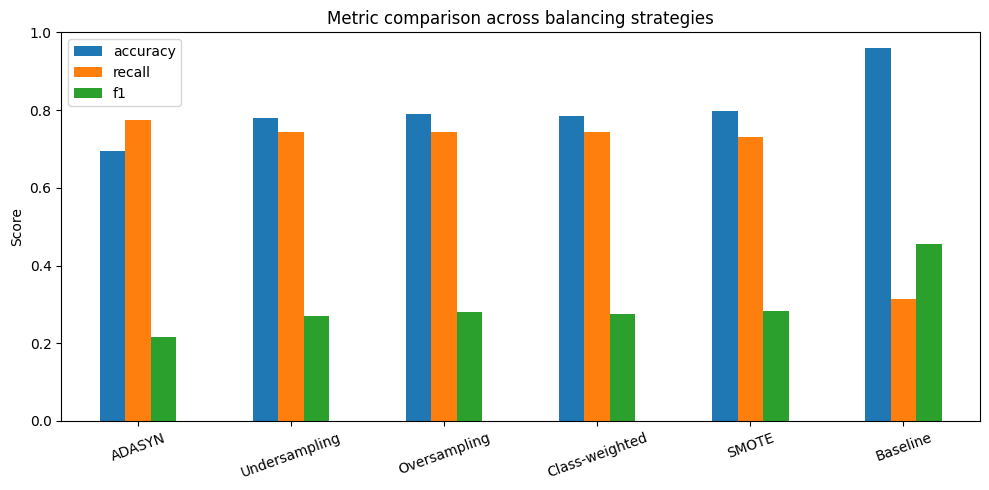

In [24]:
results_df = pd.DataFrame(results).T[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
results_df = results_df.sort_values(by='recall', ascending=False)
display(results_df.round(3))

best_recall = results_df['recall'].idxmax()
best_f1 = results_df['f1'].idxmax()

print(f'Highest recall: {best_recall} ({results_df.loc[best_recall, "recall"]:.3f})')
print(f'Highest F1 score: {best_f1} ({results_df.loc[best_f1, "f1"]:.3f})')

ax = results_df[['accuracy', 'recall', 'f1']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1), rot=20
)
ax.legend(fontsize=10)
ax.set_title('Metric comparison across balancing strategies')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()


Accuracy can be misleading in imbalanced datasets because it is dominated by the majority class. A model can get a very high accuracy just by predicting the majority class most of the time, while failing to detect the minority class that usually matters most.